# Activity 5: Used Car Price Prediction (Linear Regression)
### Implementation of Slide 20 (Part 1) of `ML_Lab_3.pptx`
**Dataset:** `car_price_prediction.csv`  
**Objective:** Predict used car prices using Linear Regression based on `Kms_Driven`, `Year`, `Engine`, and `Horsepower`.

---

### Slide 20 Instructions (Part 1):
1. **Choose features**: `Kms_Driven`, `Year`, `Engine`, `Horsepower`.
2. **Apply Linear Regression** and record performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

df = pd.read_csv("car_price_prediction.csv")
print(f"Car Price Dataset Shape: {df.shape}")
features = ['Kms_Driven', 'Year', 'Engine', 'Horsepower']
target = 'Price'
print(df[features + [target]].head(10))

Car Price Dataset Shape: (1000, 6)
   Kms_Driven  Year  Engine  Horsepower   Price
0       36705  2018    1560          94  684000
1       93291  2015    1350          85  554000
2      320000  2005    1540          95  148000
3       57376  2019    1650         125  936000
4       42133  2021    1470         129  957000
5       24438  2022    1240          92  786000
6       86519  2015    1740         124  923000
7       14714  2023    1230          74  602000
8      169733  2014    1470         107  641000
9      134455  2005    1130          92  408000


## Step 1 — Feature Exploration & Correlation

Feature Correlations with Price:
  Kms_Driven  : -0.3839
  Year        : +0.3657
  Engine      : +0.8398
  Horsepower  : +0.8896


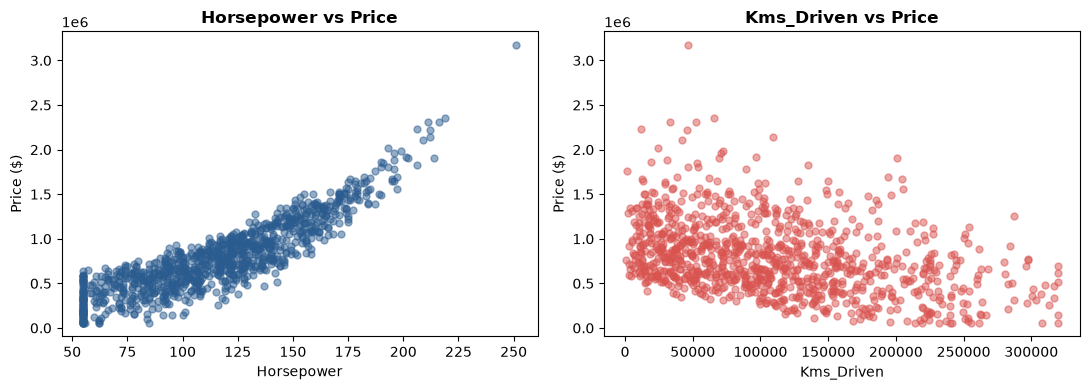

In [2]:
print("Feature Correlations with Price:")
for f in features:
    print(f"  {f:12s}: {df[f].corr(df[target]):+.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(df['Horsepower'], df['Price'], color='#2b5c8f', alpha=0.5, s=25)
axes[0].set_title("Horsepower vs Price", fontweight='bold')
axes[0].set_xlabel("Horsepower")
axes[0].set_ylabel("Price ($)")

axes[1].scatter(df['Kms_Driven'], df['Price'], color='#d9534f', alpha=0.5, s=25)
axes[1].set_title("Kms_Driven vs Price", fontweight='bold')
axes[1].set_xlabel("Kms_Driven")
axes[1].set_ylabel("Price ($)")
plt.tight_layout()
plt.show()

## Step 2 — Train/Test Split & Feature Scaling

In [3]:
X = df[features].values
y = df[target].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train_scaled.shape[0], " Testing samples:", X_test_scaled.shape[0])

Training samples: 800  Testing samples: 200


## Step 3 — Fit Linear Regression & Record Performance (Slide 20)

In [4]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_train = lr.predict(X_train_scaled)
y_pred_test = lr.predict(X_test_scaled)

tr_r2 = r2_score(y_train, y_pred_train)
te_r2 = r2_score(y_test, y_pred_test)
te_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
te_mae = mean_absolute_error(y_test, y_pred_test)

print("=" * 55)
print("     LINEAR REGRESSION MODEL PERFORMANCE (Slide 20)     ")
print("=" * 55)
print(f"  Training R² Score: {tr_r2:.4f}")
print(f"  Testing R² Score:  {te_r2:.4f}")
print(f"  Testing RMSE:      ${te_rmse:,.2f}")
print(f"  Testing MAE:       ${te_mae:,.2f}")
print("=" * 55)
print("\nModel Coefficients:")
for feat, coef in zip(features, lr.coef_):
    print(f"  {feat:12s}: {coef:+,.2f}")
print(f"  Intercept   : {lr.intercept_:+,.2f}")

     LINEAR REGRESSION MODEL PERFORMANCE (Slide 20)     
  Training R² Score: 0.9441
  Testing R² Score:  0.9352
  Testing RMSE:      $101,299.39
  Testing MAE:       $78,674.16

Model Coefficients:
  Kms_Driven  : -105,529.26
  Year        : +61,928.17
  Engine      : -8,430.71
  Horsepower  : +364,920.84
  Intercept   : +791,672.50


## Step 4 — Actual vs Predicted & Residuals Plot

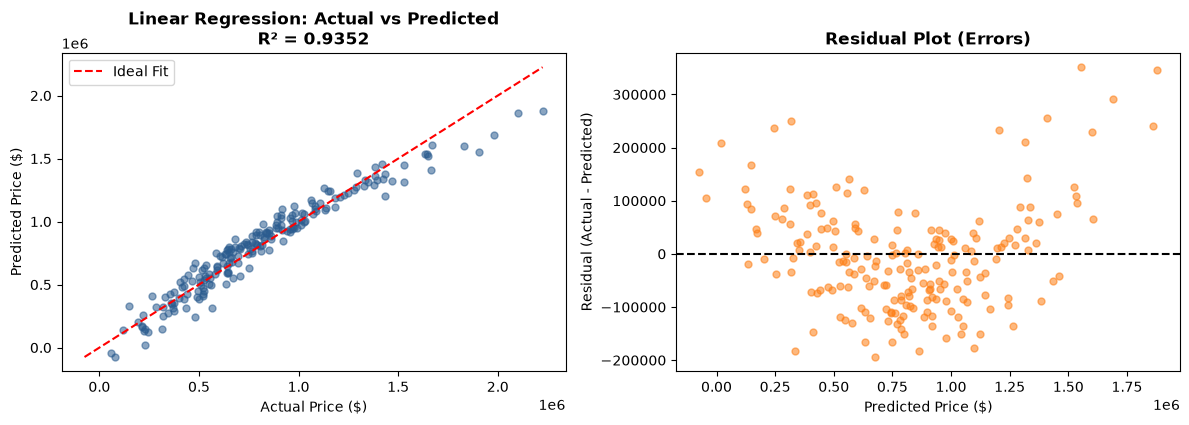

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_test, color='#2b5c8f', alpha=0.55, s=25)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Ideal Fit')
axes[0].set_title(f"Linear Regression: Actual vs Predicted\nR² = {te_r2:.4f}", fontweight='bold')
axes[0].set_xlabel("Actual Price ($)")
axes[0].set_ylabel("Predicted Price ($)")
axes[0].legend()

# Residuals
residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, color='#fd7e14', alpha=0.55, s=25)
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title("Residual Plot (Errors)", fontweight='bold')
axes[1].set_xlabel("Predicted Price ($)")
axes[1].set_ylabel("Residual (Actual - Predicted)")

plt.tight_layout()
plt.show()